# Обнаружение ботов по истории событий куки

**Задача.** Для каждой `cookie_id` из теста получить score от 0 до 1. Основная метрика — максимальный Precision среди порогов с Recall ≥ 70%. Единица оценки — кука, а не событие.

Этот ноутбук — полное воспроизводимое решение: загрузка и проверка данных, EDA, гипотезы и эксперименты, временная валидация, сравнение с baseline, обучение итоговой модели и запись `submission.csv`. Единственный локальный импорт — предоставленная функция метрики из `metric.py`. Все ячейки нужно выполнить по порядку (**Run All**) из каталога, где находятся папка `data/` и `metric.py`.

**Ограничения соблюдены:** используются только локальные классические ML-библиотеки. События после `window_end_ts`, тестовые метки, внешние API и языковые модели в решении не используются. Случайное зерно зафиксировано.

## Кратко о подходе

1. **Данные и временная корректность.** Для каждой куки учитываем только события от `window_start_ts` включительно до `window_end_ts` не включительно. Сортируем события внутри куки; `user_agent` не подаём модели.
2. **Baseline.** RandomForest использует два простых признака: число событий и число разных объявлений. Его средняя P@R≥0,7 на трёх временных срезах — 0,103.
3. **Поведенческие признаки.** Считаем темп и сессии, состав действий, глубину поиска, разнообразие и повторяемость объявлений, категорий, локаций и запросов. Добавляем число более ранних просмотров того же объявления другими куками в тот же день и характеристики перемещения курсора между событиями. Сырые идентификаторы и тексты в модель не передаём.
4. **Валидация и выбор.** Три последовательных периода: обучение только на более ранних днях, проверка на следующих трёх днях. Сравниваем варианты только по официальной `precision_at_recall` из `metric.py`. Финальный CatBoost получил 0,617 / 0,673 / 0,700, средняя — 0,663. Прирост от признаков перемещения курсора наблюдается на каждом временном срезе.
5. **Финал.** Обучаем выбранную модель на всём `train.csv`, сохраняем `cookie_id` в исходном порядке `test.csv` и записываем `submission.csv` с двумя колонками. Seed и версии библиотек зафиксированы.

Ниже показаны проверка качества событий, распределения признаков, гипотезы и их результаты. Скрытые метки теста недоступны, поэтому качество на нём может отличаться.

# 1. Окружение и воспроизводимость

Проверено с Python 3.11.0. Точные версии библиотек — в `requirements.txt`. Категориальный признак финальной модели — только нормализованная платформа. `user_agent` **исключается уже при чтении CSV**, поэтому он не влияет ни на признаки, ни на проверку дубликатов.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from metric import precision_at_recall

SEED = 42
DATA_DIR = Path('data')
EVENT_TYPES = (
    'search_results_view', 'item_view', 'photo_swipe', 'seller_page_view',
    'contact_phone_show', 'contact_chat_open', 'contact_message_sent',
    'favorite_add', 'login',
)
FOLDS = (
    ('2026-04-11', '2026-04-14'),
    ('2026-04-14', '2026-04-17'),
    ('2026-04-17', '2026-04-20'),
)
CAT_COLUMNS = ('platform_first',)

print('Python:', sys.version.split()[0])
print('NumPy:', np.__version__, 'pandas:', pd.__version__)

Python: 3.11.0
NumPy: 1.26.4 pandas: 2.3.3


# 2. Загрузка и контроль исходных данных

Одна строка метаданных соответствует одной куке. Проверяем уникальность `cookie_id`, отсутствие пересечения обучающих и тестовых ID, пустых ключей и меток вне {0,1}. Полностью одинаковые события не удаляем автоматически: повторные действия в одну секунду могут быть реальным поведением. Их частота будет отдельным признаком.

In [2]:
def load_data() -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    dates = ["cookie_created_at", "window_start_ts", "window_end_ts"]
    train = pd.read_csv(DATA_DIR / "train.csv", parse_dates=dates)
    test = pd.read_csv(DATA_DIR / "test.csv", parse_dates=dates)
    events = pd.read_csv(DATA_DIR / "events.csv.gz", parse_dates=["event_ts"],
                         usecols=lambda column: column != "user_agent")

    assert train.cookie_id.is_unique and test.cookie_id.is_unique
    assert not set(train.cookie_id).intersection(test.cookie_id)
    assert events.cookie_id.notna().all() and events.event_ts.notna().all()
    assert set(events.cookie_id).issubset(set(train.cookie_id).union(test.cookie_id))
    assert train.target.isin([0, 1]).all()
    return train, test, events

In [3]:
train, test, events = load_data()
assert 'user_agent' not in events.columns
print('Train:', train.shape, 'Test:', test.shape, 'Events без UA:', events.shape)
print('Ботов в train:', int(train.target.sum()), 'из', len(train),
      f'({train.target.mean():.2%})')
print('Точные дубликаты событий:', events.duplicated().sum())
display(train.head(3))

Train: (11091, 5) Test: (4909, 4) Events без UA: (328905, 13)
Ботов в train: 899 из 11091 (8.11%)
Точные дубликаты событий: 4863


,cookie_id,cookie_created_at,window_start_ts,window_end_ts,target
0,ck_54a059eb7d3ea68b,2025-11-21 09:30:41,2026-04-06,2026-04-07,0
1,ck_7e4de46eeab82974,2025-09-23 10:10:24,2026-04-06,2026-04-07,0
2,ck_9320229ef6304522,2026-03-04 00:08:02,2026-04-06,2026-04-07,0


## 2.1. Время: главное правило против утечки

Для каждой куки берём только события `window_start_ts <= event_ts < window_end_ts`. Сначала проверяем, где лежат остальные события. В этом наборе все показы капчи произошли **после** конца окна; такой «сильный» признак был бы недопустимой подсказкой из будущего.

In [4]:
meta = pd.concat([train.drop(columns='target'), test], ignore_index=True)
window_audit = events[['cookie_id', 'event_ts', 'event_name']].merge(
    meta[['cookie_id', 'window_start_ts', 'window_end_ts']],
    on='cookie_id', validate='many_to_one'
)
window_audit['segment'] = np.select(
    [window_audit.event_ts.lt(window_audit.window_start_ts),
     window_audit.event_ts.ge(window_audit.window_end_ts)],
    ['до окна', 'после окна'], default='внутри окна'
)
display(window_audit.segment.value_counts().rename('событий').to_frame())
display(pd.crosstab(window_audit.event_name, window_audit.segment))
window_events = window_audit.loc[window_audit.segment.eq('внутри окна'),
                                 ['cookie_id', 'event_ts', 'event_name']].copy()
del window_audit

,событий
segment,
внутри окна,288126
после окна,40779


segment,внутри окна,после окна
event_name,,
captcha_shown,0,7928
contact_chat_open,5548,577
contact_message_sent,2823,258
contact_phone_show,10288,1028
favorite_add,17296,1753
item_view,108086,12731
login,5661,606
photo_swipe,33084,3433
search_results_view,89798,10604


## 2.2. Дисбаланс, даты, пропуски и категории

Тест расположен позже обучения, поэтому случайное разбиение не покажет возможный временной сдвиг. Частоты событий и пропуски изучаем до агрегирования: `item_id`, `search_query` и координаты заполняются только для части типов событий. Разный регистр названий платформ нормализуем при построении признаков.

In [5]:
display(train.groupby(train.window_start_ts.dt.date).target
        .agg(кук='size', ботов='sum', доля_ботов='mean').round(3))
display(test.groupby(test.window_start_ts.dt.date).size().rename('кук').to_frame())
display(events.event_name.value_counts().rename('событий').to_frame())
display(events.platform.value_counts().rename('событий').to_frame())
display(events.isna().mean().round(3).rename('доля пропусков').to_frame())

,кук,ботов,доля_ботов
window_start_ts,,,
2026-04-06,772,68,0.088
2026-04-07,797,59,0.074
2026-04-08,834,70,0.084
2026-04-09,902,66,0.073
2026-04-10,912,82,0.090
2026-04-11,896,79,0.088
2026-04-12,817,67,0.082
2026-04-13,843,53,0.063
2026-04-14,826,70,0.085


,кук
window_start_ts,
2026-04-20,652
2026-04-21,628
2026-04-22,637
2026-04-23,660
2026-04-24,760
2026-04-25,759
2026-04-26,813


,событий
event_name,
item_view,120817
search_results_view,100402
photo_swipe,36517
favorite_add,19049
seller_page_view,17403
contact_phone_show,11316
captcha_shown,7928
login,6267
contact_chat_open,6125


,событий
platform,
desktop,46866
WEB,46476
Web,46365
web,45951
ANDROID,42462
Android,42254
android,42159
iphone,4103
IOS,4100


,доля пропусков
cookie_id,0.000
event_ts,0.000
eid,0.000
event_name,0.000
platform,0.000
item_id,0.348
item_category,0.100
item_location,0.072
seller_type,0.407
search_query,0.695


## 2.3. Первые поведенческие различия

Для каждого типа события считаем среднее количество на одну куку отдельно у людей и ботов. Это только описательный анализ на train: он подсказывает, какие агрегаты стоит проверить, но **не является** оценкой качества модели.

,люди,боты
event_name,,
contact_chat_open,0.33,0.42
contact_message_sent,0.17,0.23
contact_phone_show,0.62,0.76
favorite_add,1.11,0.80
item_view,6.16,12.87
login,0.36,0.23
photo_swipe,2.07,2.07
search_results_view,5.14,10.36
seller_page_view,0.90,1.74


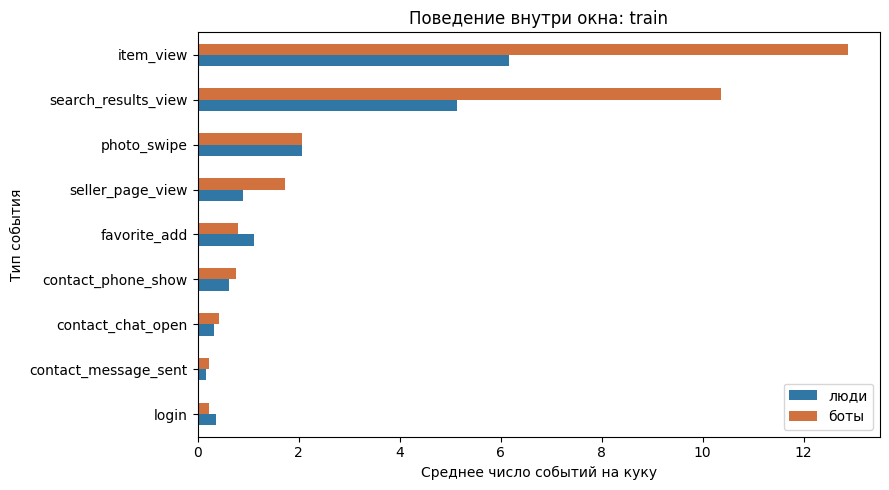

In [6]:
event_matrix = pd.crosstab(window_events.cookie_id, window_events.event_name)
event_matrix = event_matrix.reindex(train.cookie_id, fill_value=0)
event_matrix['target'] = train.target.to_numpy()
mean_events = event_matrix.groupby('target').mean().T
mean_events.columns = ['люди', 'боты']
display(mean_events.round(2))
mean_events.sort_values('боты').plot.barh(
    figsize=(9, 5), color=['#3177a5', '#d1713e']
)
plt.xlabel('Среднее число событий на куку')
plt.ylabel('Тип события')
plt.title('Поведение внутри окна: train')
plt.tight_layout()
plt.show()

## 2.4. Качество файла событий и смысл пропусков

Сырые строки не обязаны идти по времени: для каждого расчёта пауз сортируем **внутри куки** по `event_ts`, а при совпадении времени — по `eid`. Порядок переходов между событиями с одинаковым timestamp неоднозначен, поэтому такие переходы не считаем. Точные дубли могут быть как повторной записью, так и реальным повторным действием: их эффект проверим отдельной абляцией. Пропуски координат зависят от платформы; отсутствие `search_query` и `search_page` нормально вне поиска. Поэтому не заполняем всё нулями или одной строкой «нет данных»: числовые пропуски оставляем для CatBoost.

Строка User-Agent может сообщать браузер, ОС и признаки автоматизации, но сырая строка создаёт множество редких идентификаторов и может привязать модель к техническому источнику трафика. В этом решении она вообще **не загружается**. Проверяем, какую часть качества можно получить из поведения: времени, типов действий и разнообразия объявлений, категорий, локаций и запросов.

Отдельные UA вроде `python-requests` или `curl` могут быть поводом для правила в реальной антибот-системе, но такой маркер сам по себе не доказывает метку `target=1`: здесь размечен трафик конкретных сервисов сбора данных. Сопоставление UA с TLS-фингерпринтом и HTTP-заголовками могло бы выявлять несоответствия, однако этих полей в выданном датасете нет. Поэтому проверять такую гипотезу в этой задаче невозможно. Финальная модель опирается на события внутри окна и не читает UA. Обсуждение UA здесь — обоснование выбора признаков, а не шаг обучения модели.

In [7]:
raw_negative_steps = events.event_ts.diff().dt.total_seconds().lt(0).sum()
window_only = events.merge(
    meta[['cookie_id', 'window_start_ts', 'window_end_ts']],
    on='cookie_id', validate='many_to_one'
)
window_only = window_only.loc[
    window_only.event_ts.ge(window_only.window_start_ts)
    & window_only.event_ts.lt(window_only.window_end_ts)
].copy()
duplicate_rows = window_only.duplicated(subset=list(events.columns)).sum()
same_time_rows = window_only.sort_values(['cookie_id', 'event_ts', 'eid'], kind='stable')
same_time_rows = same_time_rows.duplicated(subset=['cookie_id', 'event_ts']).sum()
print('Событий внутри окна:', len(window_only))
print('Убывающих шагов времени в исходном CSV:', raw_negative_steps)
print('Точных повторов внутри окна:', duplicate_rows)
print('Событий с совпадающим временем внутри куки:', same_time_rows)
print('Пропуски по платформе, доля:')
display(window_only.assign(platform_norm=window_only.platform.fillna('unknown').str.lower())
        .groupby('platform_norm').pointer_x.apply(lambda s: s.isna().mean())
        .sort_values(ascending=False).round(3).to_frame('pointer_x_missing_share'))
del window_only

Событий внутри окна: 288126
Убывающих шагов времени в исходном CSV: 164365
Точных повторов внутри окна: 4293
Событий с совпадающим временем внутри куки: 5806
Пропуски по платформе, доля:


,pointer_x_missing_share
platform_norm,
android,1.000
ios,1.000
iphone,1.000
web,0.407
desktop,0.406


# 3. Гипотезы до обучения

1. **Агрегаты без User-Agent полезнее baseline.** Проверяем темп, глубину поиска и разнообразие действий.
2. **Структура сессий добавляет сигнал.** Проверяем паузы, серии и переходы между типами событий.
3. **Другая модель или ансамбль может помочь.** Сравниваем LightGBM и фиксированные усреднения с CatBoost.
4. **Вес редкого класса и глубина деревьев могут помочь тихим ботам.** Проверяем вес 3 и глубину 5.
5. **Платформа может быть нестабильным прокси.** Проверяем модель без неё и усреднение.
6. **Точные дубли могут искажать ритм.** Проверяем удаление повторов до агрегации.
7. **Технические поля могут давать нестабильный сигнал.** Убираем платформу, курсор и календарные поля.
8. **Более подробное время реакции может выдать тихих ботов.** Добавляем интервалы внутри коротких сессий и паузы при переходах.
9. **Смена контекста важнее простой численности действий.** Проверяем соседние объявления, категории, локации и запросы.
10. **Повторные цели сбора могут проявляться между куками.** Проверяем число более ранних просмотров того же объявления другими куками.

Все варианты сравниваем на одинаковых временных срезах официальной метрикой. Выбор делаем по совокупности периодов, а не по одному удачному дню.

# 4. Обработка и базовые признаки без UA

`cookie_id` нужен только для группировки и сохранения ответа, но не поступает в модель. Числовые пропуски сохраняются как `NaN` для CatBoost и LightGBM, бесконечные значения заменяются на пропуски. Для платформы приводим регистр к нижнему и заполняем неизвестное значением `unknown`.

Базовые группы признаков: объём действий, доли типов событий, интервалы, глубина поиска, уникальные объявления/категории/локации, концентрация интереса, доли контактов и избранного, возраст куки, наличие курсора. Сырые `item_id` и запросы модель не получает: используются только агрегаты, чтобы избежать привязки к конкретным объявлениям.

In [8]:
def add_diversity_features(out: pd.DataFrame, ev: pd.DataFrame, col: str) -> None:
    """Frequency concentration and entropy, excluding missing values."""
    counts = ev.dropna(subset=[col]).groupby(["cookie_id", col]).size()
    if counts.empty:
        return
    probs = counts / counts.groupby(level=0).transform("sum")
    out[f"{col}_max_share"] = probs.groupby(level=0).max()
    out[f"{col}_entropy"] = -(probs * np.log(probs)).groupby(level=0).sum()

### Подготовка событий и метаданных

Сначала ограничиваем историю каждой куки её собственным окном, сортируем события и рассчитываем технические поля, нужные для агрегаций. Все последующие функции работают с этой подготовленной таблицей.

In [9]:
def prepare_base_events(meta: pd.DataFrame, events: pd.DataFrame) -> pd.DataFrame:
    ev = events.merge(
        meta[['cookie_id', 'window_start_ts', 'window_end_ts']],
        on='cookie_id', how='inner', validate='many_to_one',
    )
    ev = ev.loc[
        ev.event_ts.ge(ev.window_start_ts) & ev.event_ts.lt(ev.window_end_ts)
    ].copy()
    ev = ev.sort_values(['cookie_id', 'event_ts', 'eid'], kind='stable')
    ev['gap_seconds'] = ev.groupby('cookie_id').event_ts.diff().dt.total_seconds()
    ev['platform_norm'] = ev.platform.fillna('unknown').str.lower()
    ev['hour'] = ev.event_ts.dt.hour
    ev['minute_bin'] = ev.event_ts.dt.floor('min')
    ev['five_min_bin'] = ev.event_ts.dt.floor('5min')
    ev['duplicate_event'] = ev.duplicated(subset=list(events.columns), keep='first')
    return ev

In [10]:
def add_base_activity(out: pd.DataFrame, ev: pd.DataFrame, group) -> None:
    out['cookie_age_days'] = (
        out.window_start_ts - out.cookie_created_at
    ).dt.total_seconds() / 86400
    out['cookie_created_hour'] = out.cookie_created_at.dt.hour
    out['window_weekday'] = out.window_start_ts.dt.dayofweek
    out['n_events'] = group.size()
    out['n_event_types'] = group.event_name.nunique()
    out['active_span_min'] = (
        group.event_ts.max() - group.event_ts.min()
    ).dt.total_seconds() / 60
    out['first_event_offset_min'] = (
        group.event_ts.min() - out.window_start_ts
    ).dt.total_seconds() / 60
    out['last_event_offset_min'] = (
        out.window_end_ts - group.event_ts.max()
    ).dt.total_seconds() / 60
    out['events_per_active_hour'] = out.n_events / (1 + out.active_span_min / 60)
    out['n_active_hours'] = group.hour.nunique()
    out['night_event_share'] = ev.hour.lt(6).groupby(ev.cookie_id).mean()

### Разнообразие, поиск и интервалы

Считаем уникальные значения и концентрацию интереса. Затем описываем глубину поиска и ритм событий; пропуски сохраняем, поскольку отсутствие поискового запроса или координат может быть естественным для данного события или платформы.

In [11]:
def add_base_diversity(out: pd.DataFrame, ev: pd.DataFrame, group) -> None:
    for col, name in [
        ('item_id', 'items'), ('item_category', 'categories'),
        ('item_location', 'locations'), ('seller_type', 'seller_types'),
        ('search_query', 'queries'), ('search_page', 'search_pages'),
        ('platform_norm', 'platforms'),
    ]:
        out[f'n_{name}'] = group[col].nunique()
    for col in ('item_id', 'item_category', 'item_location', 'search_query'):
        add_diversity_features(out, ev, col)

    out['search_page_mean'] = group.search_page.mean()
    out['search_page_max'] = group.search_page.max()
    out['search_page_p90'] = group.search_page.quantile(0.9)
    out['search_deep_share'] = ev.search_page.gt(5).groupby(ev.cookie_id).mean()
    out['query_length_mean'] = ev.search_query.str.len().groupby(ev.cookie_id).mean()
    out['pointer_share'] = group.pointer_x.apply(lambda x: x.notna().mean())
    out['pointer_x_nunique'] = group.pointer_x.nunique()
    out['pointer_y_nunique'] = group.pointer_y.nunique()
    out['duplicate_event_share'] = group.duplicate_event.mean()

In [12]:
def add_base_gaps(out: pd.DataFrame, ev: pd.DataFrame, group) -> None:
    for quantile, name in [
        (0.1, 'p10'), (0.25, 'p25'), (0.5, 'median'),
        (0.75, 'p75'), (0.9, 'p90'),
    ]:
        out[f'gap_{name}_seconds'] = group.gap_seconds.quantile(quantile)
    out['gap_mean_seconds'] = group.gap_seconds.mean()
    out['gap_std_seconds'] = group.gap_seconds.std()
    out['gap_cv'] = out.gap_std_seconds / (out.gap_mean_seconds + 1)
    for seconds in (0, 1, 5, 10, 30, 300):
        out[f'gap_le_{seconds}_share'] = (
            ev.gap_seconds.le(seconds).groupby(ev.cookie_id).mean()
        )
    out['max_events_per_minute'] = (
        ev.groupby(['cookie_id', 'minute_bin']).size().groupby(level=0).max()
    )
    out['max_events_per_5min'] = (
        ev.groupby(['cookie_id', 'five_min_bin']).size().groupby(level=0).max()
    )

### Состав действий и итоговая таблица

Доли действий нормируем на число событий или просмотров: одинаковое число контактов может иметь разный смысл у куки с пятью и со ста просмотрами.

In [13]:
def add_base_action_mix(out: pd.DataFrame, ev: pd.DataFrame) -> None:
    counts = pd.crosstab(ev.cookie_id, ev.event_name).reindex(out.index, fill_value=0)
    for event_name in EVENT_TYPES:
        values = counts[event_name] if event_name in counts else 0
        out[f'n_{event_name}'] = values
        out[f'share_{event_name}'] = (
            out[f'n_{event_name}'] / out.n_events.clip(lower=1)
        )
    out['n_contact_actions'] = (
        out.n_contact_phone_show + out.n_contact_chat_open
        + out.n_contact_message_sent
    )
    out['items_per_view'] = out.n_items / (1 + out.n_item_view)
    out['locations_per_item'] = out.n_locations / (1 + out.n_items)
    out['views_per_search'] = out.n_item_view / (1 + out.n_search_results_view)
    out['favorite_per_view'] = out.n_favorite_add / (1 + out.n_item_view)
    out['contact_per_view'] = out.n_contact_actions / (1 + out.n_item_view)
    out['photo_per_view'] = out.n_photo_swipe / (1 + out.n_item_view)
    out['seller_per_view'] = out.n_seller_page_view / (1 + out.n_item_view)

In [14]:
def make_features(train: pd.DataFrame, test: pd.DataFrame,
                  events: pd.DataFrame) -> pd.DataFrame:
    meta = pd.concat([train.drop(columns='target'), test], ignore_index=True)
    ev = prepare_base_events(meta, events)
    out = meta.set_index('cookie_id')
    group = ev.groupby('cookie_id')

    add_base_activity(out, ev, group)
    add_base_diversity(out, ev, group)
    add_base_gaps(out, ev, group)
    add_base_action_mix(out, ev)

    out['platform_first'] = group.first().platform_norm.fillna('unknown')
    out = out.drop(columns=['cookie_created_at', 'window_start_ts', 'window_end_ts'])
    out[list(CAT_COLUMNS)] = out[list(CAT_COLUMNS)].fillna('unknown').astype(str)
    numeric = out.columns.difference(CAT_COLUMNS)
    out[numeric] = out[numeric].replace([np.inf, -np.inf], np.nan).astype(float)
    assert out.index.is_unique and len(out) == len(meta)
    return out

In [15]:
base_features = make_features(train, test, events)
assert len(base_features) == len(train) + len(test)
assert base_features.index.is_unique
assert not any('user_agent' in column or column.startswith('ua_')
               for column in base_features.columns)
print('Базовых признаков:', base_features.shape[1])
print('Пустые значения по признакам (10 наиболее частых):')
display(base_features.isna().mean().sort_values(ascending=False).head(10).round(3).to_frame('доля'))
print('Платформа после нормализации:')
display(base_features.platform_first.value_counts().to_frame('кук'))

Базовых признаков: 78
Пустые значения по признакам (10 наиболее частых):


,доля
search_query_max_share,0.085
search_query_entropy,0.085
query_length_mean,0.085
search_page_p90,0.085
search_page_max,0.085
search_page_mean,0.085
gap_cv,0.058
gap_std_seconds,0.058
gap_mean_seconds,0.022
gap_p75_seconds,0.022


Платформа после нормализации:


,кук
platform_first,
android,6586
web,6424
desktop,2156
ios,620
iphone,214


## 4.1. Распределения выбранных агрегатов по классам

На графиках — накопленная доля кук с признаком не выше X. Кривые нормированы внутри каждого класса, поэтому дисбаланс не искажает сравнение. По X показаны значения до общего 99-го процентиля, а интервал между событиями отображён в логарифмической шкале. Для куки с одним событием интервал не определён и остаётся пропуском.

,человек: медиана,бот: медиана,человек: p90,бот: p90
n_events,12.00,20.00,37.0,67.20
gap_median_seconds,59.00,25.00,183.1,313.60
n_locations,5.00,8.00,12.0,19.00
search_page_max,4.00,7.00,9.0,20.00
cookie_age_days,61.78,18.97,163.6,139.06
favorite_per_view,0.09,0.00,0.5,0.24


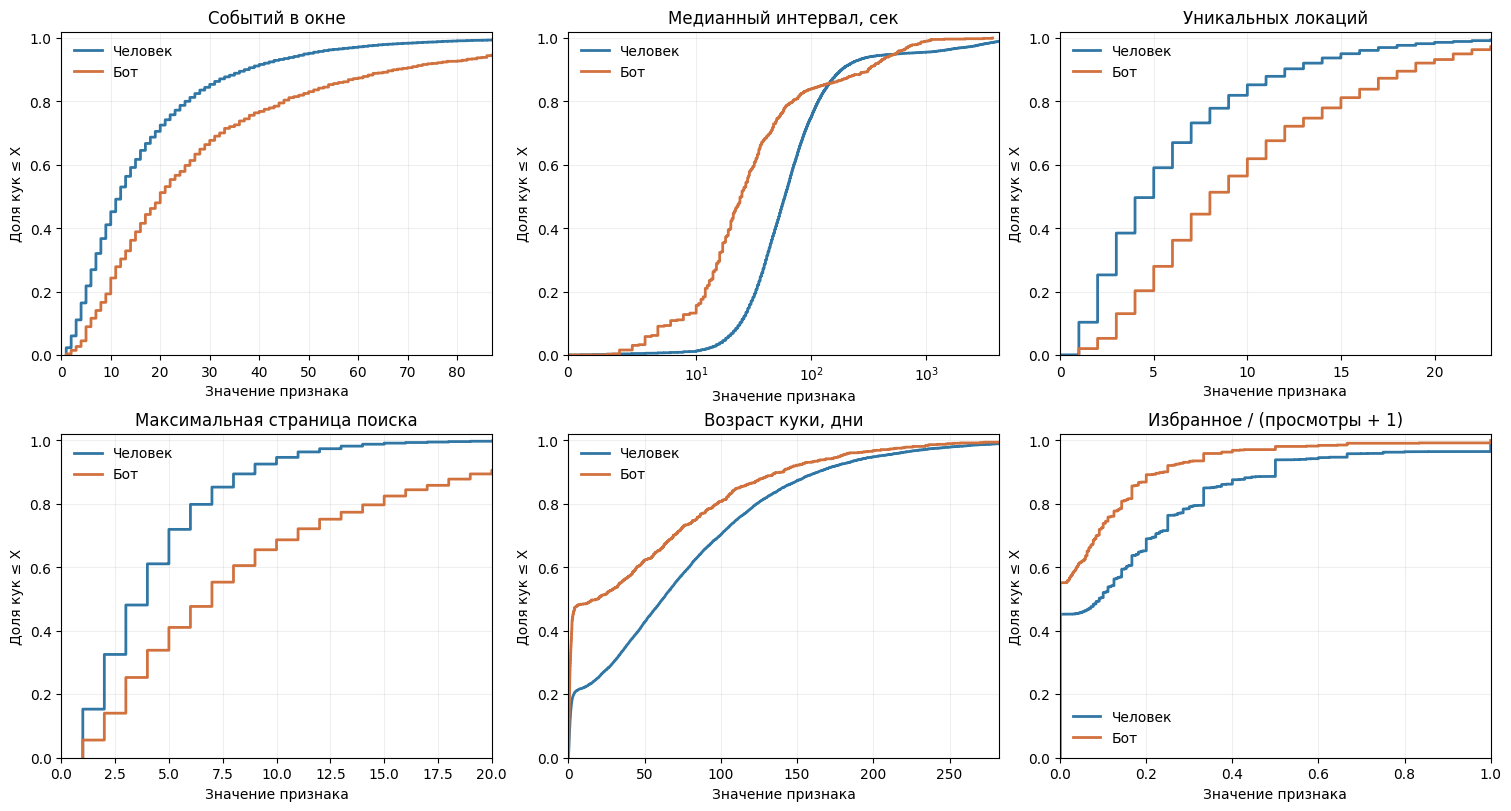

In [16]:
eda = base_features.loc[train.cookie_id].copy()
eda['target'] = train.target.to_numpy()
plot_cols = [
    ('n_events', 'Событий в окне'),
    ('gap_median_seconds', 'Медианный интервал, сек'),
    ('n_locations', 'Уникальных локаций'),
    ('search_page_max', 'Максимальная страница поиска'),
    ('cookie_age_days', 'Возраст куки, дни'),
    ('favorite_per_view', 'Избранное / (просмотры + 1)'),
]
human = eda.loc[eda.target.eq(0)]
bot = eda.loc[eda.target.eq(1)]
display(pd.DataFrame({
    'человек: медиана': human[[c for c, _ in plot_cols]].median(),
    'бот: медиана': bot[[c for c, _ in plot_cols]].median(),
    'человек: p90': human[[c for c, _ in plot_cols]].quantile(.9),
    'бот: p90': bot[[c for c, _ in plot_cols]].quantile(.9),
}).round(2))

plt.rcParams['font.family'] = 'DejaVu Sans'
fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)
for ax, (column, title) in zip(axes.flat, plot_cols):
    for part, label, color in [(human, 'Человек', '#3177a5'), (bot, 'Бот', '#d1713e')]:
        values = part[column].dropna().sort_values().to_numpy()
        ax.step(values, np.arange(1, len(values) + 1) / len(values),
                where='post', label=label, color=color, linewidth=2)
    ax.set_xlim(0, max(eda[column].quantile(.99), 1e-6))
    if column == 'gap_median_seconds':
        ax.set_xscale('symlog', linthresh=10)
    ax.set_ylim(0, 1.02)
    ax.set_title(title)
    ax.set_xlabel('Значение признака')
    ax.set_ylabel('Доля кук ≤ X')
    ax.grid(alpha=.2)
    ax.legend(frameon=False)
plt.show()

**Вывод EDA.** У ботов типично больше событий и локаций, глубже просмотр поиска, моложе куки и короче паузы. Но распределения перекрываются: отдельное правило по одному признаку будет давать много ошибок. Проверяем комбинации признаков на будущих относительно обучения днях.

# 5. Метрика и временная валидация

Код метрики ниже повторяет официальное определение из задания: равные score обрабатываются одной группой, берётся максимальный Precision по всем порогам с Recall ≥ 0,70. Другие метрики не считаем: для выбора модели используем только функцию из `metric.py`.

Срезы не пересекаются: валидация 11–13, 14–16 и 17–19 апреля; обучение для каждого среза включает только предыдущие дни. Тест — 20–26 апреля. На каждом срезе одинаковые строки для всех сравниваемых моделей.

In [17]:
# Используем именно функцию из предоставленного metric.py.
assert precision_at_recall([1, 0, 1, 1, 1], [5, 4, 3, 2, 1]) == 0.8
assert precision_at_recall([1, 1, 0, 0], [0.5] * 4) == 0.5

In [18]:
def catboost_model() -> CatBoostClassifier:
    return CatBoostClassifier(
        iterations=600,
        depth=6,
        learning_rate=0.035,
        l2_leaf_reg=5,
        loss_function="Logloss",
        random_seed=SEED,
        thread_count=4,
        verbose=False,
        allow_writing_files=False,
    )

In [19]:
validation_rows = []
predictions = {}
fold_data = {}
y = train.target.to_numpy()

for start, end in FOLDS:
    label = f'{start}..{(pd.Timestamp(end) - pd.Timedelta(days=1)).date()}'
    fit = train.window_start_ts.lt(start).to_numpy()
    valid = (train.window_start_ts.ge(start) & train.window_start_ts.lt(end)).to_numpy()
    assert fit.sum() and valid.sum()
    assert train.loc[fit, 'window_start_ts'].max() < train.loc[valid, 'window_start_ts'].min()
    fold_data[label] = (fit, valid)
    print(label, 'train:', fit.sum(), 'valid:', valid.sum(),
          'ботов в valid:', y[valid].sum())

def register(name, fold, truth, score):
    validation_rows[:] = [
        row for row in validation_rows
        if (row['model'], row['fold']) != (name, fold)
    ]
    validation_rows.append({
        'model': name, 'fold': fold,
        'p_at_r70': precision_at_recall(truth, score),
    })
    predictions[(name, fold)] = score

def results_for(*names):
    frame = pd.DataFrame(validation_rows)
    frame = frame.loc[frame.model.isin(names)].drop_duplicates(
        ['model', 'fold'], keep='last'
    )
    return frame.pivot(
        index='fold', columns='model', values='p_at_r70'
    ).round(4)

2026-04-11..2026-04-13 train: 4217 valid: 2556 ботов в valid: 199
2026-04-14..2026-04-16 train: 6773 valid: 2367 ботов в valid: 195
2026-04-17..2026-04-19 train: 9140 valid: 1951 ботов в valid: 160


# 6. Гипотеза 1 — модель без UA против baseline

Baseline повторяет quickstart: RandomForest по числу событий и уникальных объявлений. Улучшенная модель получает 78 поведенческих и метаданных признаков **без чтения User-Agent**. Для обеих моделей применяем те же три среза и фиксированный seed.

In [20]:
x_base = base_features.loc[train.cookie_id]
for fold, (fit, valid) in fold_data.items():
    baseline = RandomForestClassifier(
        n_estimators=300, min_samples_leaf=3, random_state=SEED, n_jobs=4
    )
    baseline.fit(x_base.loc[fit, ['n_events', 'n_items']].fillna(0), y[fit])
    register('baseline_rf', fold, y[valid], baseline.predict_proba(
        x_base.loc[valid, ['n_events', 'n_items']].fillna(0)
    )[:, 1])

    model = catboost_model()
    model.fit(x_base.loc[fit], y[fit], cat_features=list(CAT_COLUMNS))
    register('catboost_base_no_ua', fold, y[valid],
             model.predict_proba(x_base.loc[valid])[:, 1])
display(results_for('baseline_rf', 'catboost_base_no_ua'))

model,baseline_rf,catboost_base_no_ua
fold,,
2026-04-11..2026-04-13,0.0964,0.4828
2026-04-14..2026-04-16,0.1050,0.5209
2026-04-17..2026-04-19,0.1062,0.5957


**Проверка гипотезы 1:** подтверждена. Без UA CatBoost даёт P@R≥0,7 около 0,483 / 0,521 / 0,596 против 0,096 / 0,105 / 0,106 у baseline. Значит для обнаружения большей части ботов User-Agent не обязателен. Это не означает, что каждый агрегат полезен по отдельности.

# 7. Гипотеза 2 — ритм и последовательность действий

Две куки могут иметь одинаковое число событий, но разную структуру: одна действует равномерно, другая — короткими сериями. Добавляем число сессий при паузе более 10 минут, длины серий, повторяемость интервалов, переходы между типами событий и направление изменения номера страницы для одного запроса. События с одинаковой секундной отметкой исключаем из расчёта переходов, поскольку их порядок в файле неоднозначен.

### Сессии и паузы

Сортировка по времени нужна для вычисления соседних действий. При совпадении timestamp переход между событиями не считаем: исходный CSV перемешан и не задаёт надёжный порядок таких действий.

In [21]:
def prepare_behavior_events(train: pd.DataFrame, test: pd.DataFrame,
                            events: pd.DataFrame) -> pd.DataFrame:
    meta = pd.concat([train.drop(columns='target'), test], ignore_index=True)
    ev = events.merge(
        meta[['cookie_id', 'window_start_ts', 'window_end_ts']],
        on='cookie_id', validate='many_to_one',
    )
    ev = ev.loc[
        ev.event_ts.ge(ev.window_start_ts) & ev.event_ts.lt(ev.window_end_ts)
    ].sort_values(['cookie_id', 'event_ts', 'eid'], kind='stable').copy()
    group = ev.groupby('cookie_id')
    ev['gap'] = group.event_ts.diff().dt.total_seconds()
    ev['prev_ts'] = group.event_ts.shift()
    ev['prev_event'] = group.event_name.shift()
    ev['same_second'] = ev.event_ts.eq(ev.prev_ts)
    return ev

In [22]:
def add_session_and_gap_features(out: pd.DataFrame, ev: pd.DataFrame) -> None:
    group = ev.groupby('cookie_id')
    ev['new_session'] = ev.gap.isna() | ev.gap.gt(600)
    ev['session_number'] = ev.new_session.groupby(ev.cookie_id).cumsum()
    session_lengths = ev.groupby(['cookie_id', 'session_number']).size()
    out['n_sessions'] = session_lengths.groupby(level=0).size()
    out['max_session_events'] = session_lengths.groupby(level=0).max()
    out['mean_session_events'] = session_lengths.groupby(level=0).mean()

    gaps = ev.dropna(subset=['gap'])
    out['gap_p95'] = group.gap.quantile(.95)
    out['gap_p99'] = group.gap.quantile(.99)
    out['gap_10_60_share'] = ev.gap.between(10, 60).groupby(ev.cookie_id).mean()
    out['gap_60_300_share'] = ev.gap.between(60, 300).groupby(ev.cookie_id).mean()
    out['gap_gt_600_share'] = ev.gap.gt(600).groupby(ev.cookie_id).mean()
    medians = out.loc[gaps.cookie_id, 'gap_median_seconds'].to_numpy()
    out['gap_mad'] = gaps.assign(
        dev=(gaps.gap - medians).abs()
    ).groupby('cookie_id').dev.median()
    short_gaps = gaps.loc[gaps.gap.le(600)]
    repeated = short_gaps.groupby(['cookie_id', 'gap']).size()
    out['gap_mode_share'] = (
        repeated.groupby(level=0).max() / repeated.groupby(level=0).sum()
    )

### Переходы между типами событий

Считаем переходы между поиском, просмотром и целевыми действиями. Отдельно отслеживаем направление изменения страницы для повторений одного поискового запроса.

In [23]:
def add_transition_features(out: pd.DataFrame, ev: pd.DataFrame) -> None:
    for event_type in ['item_view', 'search_results_view']:
        sub = ev.loc[ev.event_name.eq(event_type)].copy()
        sub['type_gap'] = sub.groupby('cookie_id').event_ts.diff().dt.total_seconds()
        out[f'median_gap_{event_type}'] = sub.groupby('cookie_id').type_gap.median()

    transitions = [
        ('search_results_view', 'item_view'),
        ('item_view', 'search_results_view'),
        ('item_view', 'photo_swipe'),
        ('item_view', 'seller_page_view'),
        ('item_view', 'contact_phone_show'),
        ('item_view', 'favorite_add'),
    ]
    for previous, current in transitions:
        mask = ev.prev_event.eq(previous) & ev.event_name.eq(current) & ~ev.same_second
        out[f'transition_{previous}__{current}'] = mask.groupby(ev.cookie_id).sum()
    valid = ev.prev_event.notna() & ~ev.same_second
    out['same_type_transition_share'] = (
        (ev.event_name.eq(ev.prev_event) & valid).groupby(ev.cookie_id).sum()
        / valid.groupby(ev.cookie_id).sum()
    )

In [24]:
def add_search_progress_features(out: pd.DataFrame, ev: pd.DataFrame) -> None:
    search = ev.loc[ev.event_name.eq('search_results_view')].copy()
    search['page_delta'] = search.groupby(
        ['cookie_id', 'search_query'], dropna=False
    ).search_page.diff()
    out['page_step_1_share'] = search.page_delta.eq(1).groupby(search.cookie_id).mean()
    out['page_forward_share'] = search.page_delta.gt(0).groupby(search.cookie_id).mean()
    out['page_back_share'] = search.page_delta.lt(0).groupby(search.cookie_id).mean()

In [25]:
def add_behavior_features(features: pd.DataFrame, train: pd.DataFrame,
                          test: pd.DataFrame, events: pd.DataFrame) -> pd.DataFrame:
    ev = prepare_behavior_events(train, test, events)
    out = features.copy()
    add_session_and_gap_features(out, ev)
    add_transition_features(out, ev)
    add_search_progress_features(out, ev)
    numeric = out.columns.difference(CAT_COLUMNS)
    out[numeric] = out[numeric].replace([np.inf, -np.inf], np.nan).astype(float)
    return out

In [26]:
features = add_behavior_features(base_features, train, test, events)
assert features.index.equals(base_features.index)
assert 'user_agent' not in events.columns
print('После добавления структуры поведения:', features.shape[1], 'признаков')
x = features.loc[train.cookie_id]
for fold, (fit, valid) in fold_data.items():
    model = catboost_model()
    model.fit(x.loc[fit], y[fit], cat_features=list(CAT_COLUMNS))
    register('catboost_behavior', fold, y[valid],
             model.predict_proba(x.loc[valid])[:, 1])
display(results_for('catboost_base_no_ua', 'catboost_behavior'))

После добавления структуры поведения: 100 признаков


model,catboost_base_no_ua,catboost_behavior
fold,,
2026-04-11..2026-04-13,0.4828,0.5426
2026-04-14..2026-04-16,0.5209,0.5189
2026-04-17..2026-04-19,0.5957,0.6022


**Проверка гипотезы 2:** в целом подтверждена. Дополнительные признаки увеличили P@R≥0,7 на первом и последнем срезах; на среднем результат почти не изменился. Поэтому сохраняем их как часть итоговой модели, но не утверждаем, что каждый новый признак полезен.

# 8. Гипотеза 3 — LightGBM и ансамбль

LightGBM — другой локальный градиентный бустинг. Сравним его с CatBoost на **тех же** 100 признаках. Затем проверим два заранее заданных ансамбля с равными весами: среднее вероятностей и среднее процентных рангов. На валидации не подбираем оптимальные веса, чтобы не переобучиться на небольшом числе ботов.

In [27]:
x_lgb = x.copy()
x_lgb['platform_first'] = pd.Categorical(
    x_lgb['platform_first'], categories=sorted(features.platform_first.unique())
)
for fold, (fit, valid) in fold_data.items():
    lgb = LGBMClassifier(
        n_estimators=800, learning_rate=0.03, num_leaves=15,
        min_child_samples=30, colsample_bytree=0.9, reg_lambda=5,
        random_state=SEED, n_jobs=4, verbosity=-1
    )
    lgb.fit(x_lgb.loc[fit], y[fit])
    p_lgb = lgb.predict_proba(x_lgb.loc[valid])[:, 1]
    p_cb = predictions[('catboost_behavior', fold)]
    register('lightgbm', fold, y[valid], p_lgb)
    register('blend_prob', fold, y[valid], (p_cb + p_lgb) / 2)
    rank_cb = pd.Series(p_cb).rank(pct=True).to_numpy()
    rank_lgb = pd.Series(p_lgb).rank(pct=True).to_numpy()
    register('blend_rank', fold, y[valid], (rank_cb + rank_lgb) / 2)
display(results_for('catboost_behavior', 'lightgbm', 'blend_prob', 'blend_rank'))

model,blend_prob,blend_rank,catboost_behavior,lightgbm
fold,,,,
2026-04-11..2026-04-13,0.5283,0.5243,0.5426,0.4862
2026-04-14..2026-04-16,0.4841,0.4911,0.5189,0.4434
2026-04-17..2026-04-19,0.6087,0.6108,0.6022,0.5463


**Проверка гипотезы 3:** не подтверждена на совокупности срезов. LightGBM слабее CatBoost по основной метрике на каждом периоде. Усреднение слегка помогло на последнем периоде, но ухудшило первые два, поэтому финальное решение не усложняем ансамблем.

# 9. Гипотеза 4 — вес редкого класса и глубина деревьев

У ботов есть менее активная группа, похожая на людей. Проверяем умеренный вес ботов 3 при прежней глубине 6 и отдельный вариант с глубиной 5 и 850 деревьями. Остальные параметры и разбиения фиксированы. Никаких значений score по тесту для выбора не используем.

In [28]:
for fold, (fit, valid) in fold_data.items():
    weighted = CatBoostClassifier(
        iterations=600, depth=6, learning_rate=0.035, l2_leaf_reg=5,
        class_weights=[1, 3], loss_function='Logloss', random_seed=SEED,
        thread_count=4, verbose=False, allow_writing_files=False
    )
    weighted.fit(x.loc[fit], y[fit], cat_features=list(CAT_COLUMNS))
    register('class_weight_3', fold, y[valid],
             weighted.predict_proba(x.loc[valid])[:, 1])

    shallow = CatBoostClassifier(
        iterations=850, depth=5, learning_rate=0.035, l2_leaf_reg=5,
        loss_function='Logloss', random_seed=SEED,
        thread_count=4, verbose=False, allow_writing_files=False
    )
    shallow.fit(x.loc[fit], y[fit], cat_features=list(CAT_COLUMNS))
    register('depth_5', fold, y[valid],
             shallow.predict_proba(x.loc[valid])[:, 1])
display(results_for('catboost_behavior', 'class_weight_3', 'depth_5'))

model,catboost_behavior,class_weight_3,depth_5
fold,,,
2026-04-11..2026-04-13,0.5426,0.5490,0.4795
2026-04-14..2026-04-16,0.5189,0.4946,0.5229
2026-04-17..2026-04-19,0.6022,0.5744,0.5825


**Проверка гипотезы 4:** не подтверждена устойчиво. Оба варианта помогли на отдельных срезах, но по трём периодам уступили исходной конфигурации CatBoost. Не выбираем гиперпараметры по одному лучшему числу.

# 10. Гипотеза 5 — убрать платформу

User-Agent уже отсутствует. Платформа — отдельное поле, но оно тоже может выступать техническим прокси. Обучим вариант только на поведенческих и временных признаках, затем проверим равновесное усреднение с основной моделью. Это проверка устойчивости, а не скрытая ручная корректировка теста.

In [29]:
x_no_platform = x.drop(columns=['platform_first', 'n_platforms'])
for fold, (fit, valid) in fold_data.items():
    no_platform = catboost_model()
    no_platform.fit(x_no_platform.loc[fit], y[fit])
    p_np = no_platform.predict_proba(x_no_platform.loc[valid])[:, 1]
    p_cb = predictions[('catboost_behavior', fold)]
    register('no_platform', fold, y[valid], p_np)
    register('platform_blend', fold, y[valid], (p_np + p_cb) / 2)
display(results_for('catboost_behavior', 'no_platform', 'platform_blend'))

model,catboost_behavior,no_platform,platform_blend
fold,,,
2026-04-11..2026-04-13,0.5426,0.4403,0.4947
2026-04-14..2026-04-16,0.5189,0.5037,0.4946
2026-04-17..2026-04-19,0.6022,0.6437,0.6162


**Проверка гипотезы 5:** вариант без платформы получил 0,644 на ближайшем к тесту срезе, но на первом упал до 0,440. Усреднение не устранило проблему. Это показывает, почему выбор только по последним трём дням был бы рискованным; в финале оставляем платформу.

# 11. Дополнительные проверки признаков

## 11.1. Гипотеза 6 — удалить точные дубли

Точные дубли меняют число событий, паузы и последовательности. Проверяем удаление полных повторов **до** построения признаков. Удаляем также `duplicate_event_share`, который после этой операции всегда равен нулю. Обучение и временные срезы те же.

In [30]:
dedup_events = events.drop_duplicates()
dedup_base = make_features(train, test, dedup_events)
dedup_features = add_behavior_features(dedup_base, train, test, dedup_events)
dedup_features = dedup_features.drop(columns=['duplicate_event_share'])
print('Удалено точных повторов во всём файле:', len(events) - len(dedup_events))
x_dedup = dedup_features.loc[train.cookie_id]
for fold, (fit, valid) in fold_data.items():
    model = catboost_model()
    model.fit(x_dedup.loc[fit], y[fit], cat_features=list(CAT_COLUMNS))
    register('catboost_dedup', fold, y[valid],
             model.predict_proba(x_dedup.loc[valid])[:, 1])
display(results_for('catboost_behavior', 'catboost_dedup'))

Удалено точных повторов во всём файле: 4863


model,catboost_behavior,catboost_dedup
fold,,
2026-04-11..2026-04-13,0.5426,0.5018
2026-04-14..2026-04-16,0.5189,0.5290
2026-04-17..2026-04-19,0.6022,0.5855


**Проверка гипотезы 6:** 0,502 / 0,529 / 0,586 против 0,543 / 0,519 / 0,602 у текущей модели. Средняя метрика снизилась с 0,555 до 0,539. Поэтому сохраняем исходные события и используем долю повторов как признак. Совпадающие записи не считаем доказанной ошибкой сбора данных.

## 11.2. Гипотеза 7 — убрать технические признаки

`platform_first`, число платформ, доступность и разнообразие координат курсора, час создания куки и день недели окна могут описывать клиентское устройство или источник трафика сильнее, чем поведение. Проверим их совместное удаление; возраст куки оставим, поскольку он описывает её историю. `user_agent` по-прежнему отсутствует.

In [31]:
technical_columns = [
    'platform_first', 'n_platforms', 'pointer_share',
    'pointer_x_nunique', 'pointer_y_nunique',
    'cookie_created_hour', 'window_weekday',
]
x_no_technical = x.drop(columns=technical_columns)
for fold, (fit, valid) in fold_data.items():
    model = catboost_model()
    model.fit(x_no_technical.loc[fit], y[fit])
    register('catboost_no_technical', fold, y[valid],
             model.predict_proba(x_no_technical.loc[valid])[:, 1])
display(results_for('catboost_behavior', 'catboost_no_technical'))

model,catboost_behavior,catboost_no_technical
fold,,
2026-04-11..2026-04-13,0.5426,0.5000
2026-04-14..2026-04-16,0.5189,0.5310
2026-04-17..2026-04-19,0.6022,0.6022


**Проверка гипотезы 7:** 0,500 / 0,531 / 0,602, средняя 0,544. Исключение технической группы не повысило основную метрику. Первый период ухудшился; в финале признаки оставлены, но на тесте возможен сдвиг в составе устройств. Ранее отдельная проверка без платформы тоже дала большой разброс по срезам.

## 11.3. Гипотеза 8 — время реакции внутри действий

Для каждого события берём только **положительный** интервал от предыдущего события той же куки и не длиннее десяти минут. Нулевые интервалы исключаем из переходов: при одинаковом timestamp порядок действий неизвестен. Проверим распределение таких интервалов, регулярность пауз и время переходов «поиск → объявление», «объявление → объявление», «объявление → поиск/контакт». Это попытка обнаружить менее активных ботов по ритму, а не по числу событий.

In [32]:
def add_timing_features(features: pd.DataFrame, train: pd.DataFrame,
                        test: pd.DataFrame, events: pd.DataFrame) -> pd.DataFrame:
    meta = pd.concat([train.drop(columns='target'), test], ignore_index=True)
    ev = events.merge(meta[['cookie_id', 'window_start_ts', 'window_end_ts']],
                      on='cookie_id', validate='many_to_one')
    ev = ev.loc[
        ev.event_ts.ge(ev.window_start_ts) & ev.event_ts.lt(ev.window_end_ts)
    ].sort_values(['cookie_id', 'event_ts', 'eid'], kind='stable').copy()
    group = ev.groupby('cookie_id')
    ev['gap'] = group.event_ts.diff().dt.total_seconds()
    ev['prev_event'] = group.event_name.shift()
    out = features.copy()
    short = ev.loc[ev.gap.gt(0) & ev.gap.le(600)].copy()
    gaps = short.groupby('cookie_id').gap
    out['positive_short_gap_p10'] = gaps.quantile(.10)
    out['positive_short_gap_median'] = gaps.median()
    out['positive_short_gap_p90'] = gaps.quantile(.90)
    out['positive_short_gap_cv'] = gaps.std() / (gaps.mean() + 1)
    out['positive_short_gap_unique_share'] = gaps.nunique() / gaps.size()
    out['positive_short_gap_mult_5_share'] = short.gap.mod(5).eq(0).groupby(short.cookie_id).mean()
    out['positive_short_gap_mult_10_share'] = short.gap.mod(10).eq(0).groupby(short.cookie_id).mean()
    out['positive_short_gap_le_30_share'] = short.gap.le(30).groupby(short.cookie_id).mean()
    out['positive_short_gap_count'] = gaps.size()
    transitions = [
        ('search_results_view', 'item_view'),
        ('item_view', 'item_view'),
        ('item_view', 'search_results_view'),
        ('item_view', 'contact_phone_show'),
        ('item_view', 'contact_chat_open'),
    ]
    for previous, current in transitions:
        sub = short.loc[short.prev_event.eq(previous) & short.event_name.eq(current)]
        label = f'transition_gap_{previous}__{current}'
        out[f'{label}_median'] = sub.groupby('cookie_id').gap.median()
        out[f'{label}_le_30_share'] = sub.gap.le(30).groupby(sub.cookie_id).mean()
    numeric = out.columns.difference(CAT_COLUMNS)
    out[numeric] = out[numeric].replace([np.inf, -np.inf], np.nan).astype(float)
    return out


In [33]:
timing_features = add_timing_features(features, train, test, events)
print('Признаков с расширенными паузами:', timing_features.shape[1])
x_timing = timing_features.loc[train.cookie_id]
for fold, (fit, valid) in fold_data.items():
    model = catboost_model()
    model.fit(x_timing.loc[fit], y[fit], cat_features=list(CAT_COLUMNS))
    register('catboost_timing', fold, y[valid],
             model.predict_proba(x_timing.loc[valid])[:, 1])
display(results_for('catboost_behavior', 'catboost_timing'))

Признаков с расширенными паузами: 119


model,catboost_behavior,catboost_timing
fold,,
2026-04-11..2026-04-13,0.5426,0.4828
2026-04-14..2026-04-16,0.5189,0.5373
2026-04-17..2026-04-19,0.6022,0.5628


**Проверка гипотезы 8:** 0,483 / 0,537 / 0,563, средняя 0,528. Новые интервалы улучшили только средний срез и ухудшили два других. Короткие паузы действительно несут сигнал, но базовый набор уже содержит их квантили и доли. Дополнительная детализация переходов в этом размере выборки не оправдалась.

## 11.4. Гипотеза 9 — разнообразие и смена контекста в последовательности

Простое число уникальных объявлений не показывает, возвращается ли кука к прежнему объявлению и переключается ли между категориями, городами и запросами. Для каждого поля сравниваем соседние события внутри окна с разным временем. Также считаем разнообразие категорий и локаций отдельно при поиске и просмотре объявления. Новые признаки не используют метки, `cookie_id` или события после конца окна. Проверяем ту же CatBoost на трёх временных срезах.

In [34]:
def add_sequence_diversity_features(features: pd.DataFrame, train: pd.DataFrame,
                                    test: pd.DataFrame, events: pd.DataFrame) -> pd.DataFrame:
    meta = pd.concat([train.drop(columns='target'), test], ignore_index=True)
    ev = events.merge(meta[['cookie_id', 'window_start_ts', 'window_end_ts']],
                      on='cookie_id', validate='many_to_one')
    ev = ev.loc[
        ev.event_ts.ge(ev.window_start_ts) & ev.event_ts.lt(ev.window_end_ts)
    ].sort_values(['cookie_id', 'event_ts', 'eid'], kind='stable').copy()
    group = ev.groupby('cookie_id')
    ev['gap'] = group.event_ts.diff().dt.total_seconds()
    out = features.copy()
    for col in ['item_id', 'item_category', 'item_location', 'search_query', 'search_page']:
        previous = group[col].shift()
        valid = ev[col].notna() & previous.notna() & ev.gap.gt(0)
        same = ev[col].eq(previous) & valid
        out[f'{col}_adjacent_same_share'] = (
            same.groupby(ev.cookie_id).sum() / valid.groupby(ev.cookie_id).sum()
        )
        out[f'{col}_adjacent_pairs'] = valid.groupby(ev.cookie_id).sum()
    for event_type in ['search_results_view', 'item_view']:
        sub = ev.loc[ev.event_name.eq(event_type)]
        for col in ['item_category', 'item_location']:
            out[f'{event_type}_{col}_nunique'] = sub.groupby('cookie_id')[col].nunique()
            out[f'{event_type}_{col}_per_event'] = (
                out[f'{event_type}_{col}_nunique'] / (1 + sub.groupby('cookie_id').size())
            )
    search = ev.loc[ev.event_name.eq('search_results_view')]
    out['search_page_1_share'] = search.search_page.eq(1).groupby(search.cookie_id).mean()
    out['search_page_ge_10_share'] = search.search_page.ge(10).groupby(search.cookie_id).mean()
    out['query_per_search'] = (
        search.groupby('cookie_id').search_query.nunique()
        / (1 + search.groupby('cookie_id').size())
    )
    numeric = out.columns.difference(CAT_COLUMNS)
    out[numeric] = out[numeric].replace([np.inf, -np.inf], np.nan).astype(float)
    return out


In [35]:
sequence_features = add_sequence_diversity_features(features, train, test, events)
x_sequence = sequence_features.loc[train.cookie_id]
for fold, (fit, valid) in fold_data.items():
    model = catboost_model()
    model.fit(x_sequence.loc[fit], y[fit], cat_features=list(CAT_COLUMNS))
    register('catboost_sequence', fold, y[valid],
             model.predict_proba(x_sequence.loc[valid])[:, 1])
display(results_for('catboost_behavior', 'catboost_sequence'))

model,catboost_behavior,catboost_sequence
fold,,
2026-04-11..2026-04-13,0.5426,0.5447
2026-04-14..2026-04-16,0.5189,0.5458
2026-04-17..2026-04-19,0.6022,0.6087


**Проверка гипотезы 9:** P@R≥0,7 выросла на всех трёх срезах: 0,545 / 0,546 / 0,609 против 0,543 / 0,519 / 0,602. Средняя выросла с 0,555 до 0,566. Значит, важно не только сколько разных объектов увидела кука, но и как часто она переключает контекст. Ниже проверим, можно ли усилить этот вариант настройкой модели.

## 11.5. Гипотеза 10 — повторные просмотры объявления другими куками

Если несколько кук быстро просматривают одни и те же объявления, это может быть сигналом автоматизированного сбора. Для каждого `item_view` считаем, сколько **других** кук уже просмотрели то же объявление ранее в тот же календарный день. События после текущего момента не попадают в счётчик: `rank(method='min')` даёт одинаковое число просмотрам с одинаковым timestamp, затем вычитаем прежние просмотры самой куки. Это вычисление использует только поля событий, без `target` и без User-Agent. Сначала оставляем только события внутри окон каждой куки, затем агрегируем среднюю/максимальную популярность и долю просмотров уже виденных объявлений.

In [36]:
def add_prior_item_popularity(features: pd.DataFrame, train: pd.DataFrame,
                              test: pd.DataFrame, events: pd.DataFrame) -> pd.DataFrame:
    meta = pd.concat([train.drop(columns='target'), test], ignore_index=True)
    views = events.loc[
        events.event_name.eq('item_view') & events.item_id.notna(),
        ['cookie_id', 'event_ts', 'item_id']
    ].merge(meta[['cookie_id', 'window_start_ts', 'window_end_ts']],
            on='cookie_id', validate='many_to_one')
    views = views.loc[
        views.event_ts.ge(views.window_start_ts)
        & views.event_ts.lt(views.window_end_ts)
    ].copy()
    views['event_date'] = views.event_ts.dt.date
    # Ранг с method='min' считает только строго более ранние события.
    prior_all = views.groupby(['item_id', 'event_date']).event_ts.rank(method='min') - 1
    prior_self = views.groupby(['cookie_id', 'item_id', 'event_date']).event_ts.rank(method='min') - 1
    views['prior_other_views'] = prior_all - prior_self
    out = features.copy()
    group = views.groupby('cookie_id').prior_other_views
    out['item_prior_other_mean'] = group.mean()
    out['item_prior_other_max'] = group.max()
    out['item_prior_other_seen_share'] = (
        views.prior_other_views.gt(0).groupby(views.cookie_id).mean()
    )
    out['item_prior_other_ge2_share'] = (
        views.prior_other_views.ge(2).groupby(views.cookie_id).mean()
    )
    return out


In [37]:
popularity_features = add_prior_item_popularity(sequence_features, train, test, events)
x_popularity = popularity_features.loc[train.cookie_id]
for fold, (fit, valid) in fold_data.items():
    model = catboost_model()
    model.fit(x_popularity.loc[fit], y[fit], cat_features=list(CAT_COLUMNS))
    register('catboost_prior_popularity', fold, y[valid],
             model.predict_proba(x_popularity.loc[valid])[:, 1])
display(results_for('catboost_sequence', 'catboost_prior_popularity'))

model,catboost_prior_popularity,catboost_sequence
fold,,
2026-04-11..2026-04-13,0.5323,0.5447
2026-04-14..2026-04-16,0.5437,0.5458
2026-04-17..2026-04-19,0.6328,0.6087


**Проверка гипотезы 10:** 0,532 / 0,544 / 0,633 против 0,545 / 0,546 / 0,609 у модели без этих четырёх признаков. Средняя P@R≥0,7 выросла с 0,566 до 0,570, но выигрыш обеспечен последним срезом; на первых двух есть небольшое ухудшение. Это ограничение учитываем при интерпретации, а вариант выбираем по заранее принятому правилу — среднему результату трёх временных срезов. Счётчики используют лишь события, уже произошедшие к моменту наблюдения.

## 11.6. Гипотеза 11 — движение курсора между событиями

Если доступна пара координат курсора, можно измерить расстояние между соседними точками и скорость перемещения. Это описывает движение внутри наблюдаемого потока, а не модель браузера или строку User-Agent. Для мобильных событий координаты чаще отсутствуют: оставляем такие признаки пропущенными и сохраняем признак платформы.

Используем только события внутри окна куки. Между точками с одинаковым временем порядок не определён, поэтому учитываем только пары с положительной разницей времени. Проверяем гипотезу тем же CatBoost и на тех же трёх временных срезах, сравнивая с моделью без этой группы признаков.

In [38]:
def prepare_pointer_motion(train: pd.DataFrame, test: pd.DataFrame,
                           events: pd.DataFrame) -> pd.DataFrame:
    ev = prepare_behavior_events(train, test, events)
    pointer = ev.dropna(subset=['pointer_x', 'pointer_y']).copy()
    group = pointer.groupby('cookie_id')
    pointer['dx'] = group.pointer_x.diff()
    pointer['dy'] = group.pointer_y.diff()
    pointer['pointer_gap'] = group.event_ts.diff().dt.total_seconds()
    pointer = pointer.loc[pointer.pointer_gap.gt(0)].copy()
    pointer['pointer_distance'] = np.hypot(pointer.dx, pointer.dy)
    pointer['pointer_speed'] = pointer.pointer_distance / pointer.pointer_gap
    return pointer


In [39]:
def add_pointer_motion_features(features: pd.DataFrame,
                                pointer: pd.DataFrame) -> pd.DataFrame:
    out = features.copy()
    group = pointer.groupby('cookie_id')
    out['pointer_move_count'] = group.size()
    out['pointer_dist_median'] = group.pointer_distance.median()
    out['pointer_dist_mean'] = group.pointer_distance.mean()
    out['pointer_dist_p90'] = group.pointer_distance.quantile(0.9)
    out['pointer_dist_cv'] = (
        group.pointer_distance.std() / (group.pointer_distance.mean() + 1)
    )
    out['pointer_dist_le_300_share'] = (
        pointer.pointer_distance.le(300).groupby(pointer.cookie_id).mean()
    )
    out['pointer_dist_ge_1000_share'] = (
        pointer.pointer_distance.ge(1000).groupby(pointer.cookie_id).mean()
    )
    out['pointer_speed_median'] = group.pointer_speed.median()
    out['pointer_speed_p90'] = group.pointer_speed.quantile(0.9)
    return out

pointer_events = prepare_pointer_motion(train, test, events)
pointer_features = add_pointer_motion_features(popularity_features, pointer_events)
print('Признаков после гипотезы 11:', pointer_features.shape[1])


Признаков после гипотезы 11: 134


In [40]:
pointer_diagnostic = pd.DataFrame({
    'target': train.target.to_numpy(),
    'distance': pointer_features.loc[train.cookie_id, 'pointer_dist_median'].to_numpy(),
})
display(pointer_diagnostic.groupby('target').distance.agg(['count', 'median']).round(1))


,count,median
target,,
0,3669,758.3
1,250,352.5


In [41]:
x_pointer = pointer_features.loc[train.cookie_id]
for fold, (fit, valid) in fold_data.items():
    model = catboost_model()
    model.fit(x_pointer.loc[fit], y[fit], cat_features=list(CAT_COLUMNS))
    register('catboost_pointer_motion', fold, y[valid],
             model.predict_proba(x_pointer.loc[valid])[:, 1])
display(results_for('catboost_prior_popularity', 'catboost_pointer_motion'))


model,catboost_pointer_motion,catboost_prior_popularity
fold,,
2026-04-11..2026-04-13,0.6167,0.5323
2026-04-14..2026-04-16,0.6732,0.5437
2026-04-17..2026-04-19,0.7000,0.6328


**Проверка гипотезы 11:** P@R≥0,7 выросла с 0,532 / 0,544 / 0,633 до **0,617 / 0,673 / 0,700**. Среднее по трём периодам — **0,663** вместо 0,570. Это устойчивее прежних небольших улучшений: выигрыш наблюдается на каждом временном срезе.

Координаты есть не у всех кук. Для них новые значения остаются пропущенными; модель использует остальные признаки. Расстояние измеряется в исходных координатах событий, поэтому переносимость на другой интерфейс или разрешение экрана может быть ограничена.

# 12. Сводное сравнение и выбор модели

Ниже все эксперименты в одной таблице. Для выбора смотрим на среднее и разброс P@R≥0,7 по трём временным периодам, а также на последний период как наиболее близкий к тесту. Официальная метрика перебирает порог самостоятельно; порог не включаем в `submission.csv`.

In [42]:
validation_results = pd.DataFrame(validation_rows).drop_duplicates(
    ['model', 'fold'], keep='last'
)
display(validation_results.pivot(index='model', columns='fold',
                                 values='p_at_r70').round(4))
summary = validation_results.groupby('model').agg(
    mean_p_at_r70=('p_at_r70', 'mean'),
    min_p_at_r70=('p_at_r70', 'min'),
).sort_values('mean_p_at_r70', ascending=False)
display(summary.round(4))
validation_results.to_csv('validation_results.csv', index=False)

fold,2026-04-11..2026-04-13,2026-04-14..2026-04-16,2026-04-17..2026-04-19
model,,,
baseline_rf,0.0964,0.1050,0.1062
blend_prob,0.5283,0.4841,0.6087
blend_rank,0.5243,0.4911,0.6108
catboost_base_no_ua,0.4828,0.5209,0.5957
catboost_behavior,0.5426,0.5189,0.6022
catboost_dedup,0.5018,0.5290,0.5855
catboost_no_technical,0.5000,0.5310,0.6022
catboost_pointer_motion,0.6167,0.6732,0.7000
catboost_prior_popularity,0.5323,0.5437,0.6328


,mean_p_at_r70,min_p_at_r70
model,,
catboost_pointer_motion,0.6633,0.6167
catboost_prior_popularity,0.5696,0.5323
catboost_sequence,0.5664,0.5447
catboost_behavior,0.5546,0.5189
catboost_no_technical,0.5444,0.5000
blend_rank,0.5421,0.4911
blend_prob,0.5404,0.4841
class_weight_3,0.5393,0.4946
catboost_dedup,0.5387,0.5018


По средней официальной метрике на трёх временных срезах выбираем **CatBoost с признаками поведения, прошлой популярности объявлений и движения курсора, без User-Agent**. P@R≥0,7: **0,617 / 0,673 / 0,700**, средняя **0,663**. Исходный baseline RandomForest даёт 0,103 в среднем, предыдущая модель без признаков движения курсора — 0,570. Выбор основан только на P@R≥0,7 из metric.py.

Удаление дублей, расширенные интервалы и исключение технических полей не дали устойчивого выигрыша. В финальный расчёт включены только признаки, доступные к концу окна каждой куки.

# 13. Финальная модель и файл для отправки

Обучаем выбранную конфигурацию на всех размеченных куках и получаем непрерывные вероятности для теста. Проверяем точное совпадение списка и порядка `cookie_id`, отсутствие пропусков и дубликатов, диапазон score и ровно две колонки.

In [43]:
final_model = catboost_model()
final_model.fit(
    pointer_features.loc[train.cookie_id], train.target,
    cat_features=list(CAT_COLUMNS)
)
submission = pd.DataFrame({
    'cookie_id': test.cookie_id,
    'score': final_model.predict_proba(pointer_features.loc[test.cookie_id])[:, 1]
})
assert list(submission.columns) == ['cookie_id', 'score']
assert submission.cookie_id.is_unique
assert submission.cookie_id.equals(test.cookie_id)
assert submission.score.notna().all() and submission.score.between(0, 1).all()
submission.to_csv('submission.csv', index=False)
print('Сохранено строк:', len(submission))
print('Диапазон score:', submission.score.min(), submission.score.max())
display(submission.head())

Сохранено строк: 4909
Диапазон score: 0.00045244660255211536 0.9972964029663456


,cookie_id,score
0,ck_315fb710a0e371e7,0.001119
1,ck_a76ee3b3e3e522fd,0.081283
2,ck_94c9a4d382689e82,0.051495
3,ck_8eaf9509ad9462a0,0.004529
4,ck_9a88a5a989cb5bc6,0.006281


## 13.1. Интерпретация и контроль повторного запуска

Покажем наиболее значимые признаки финального CatBoost. Их важности относятся только к обученной модели и не означают причинного влияния. Контрольная SHA-256 сумма позволяет проверить идентичность файла при повторном запуске в той же среде.

In [44]:
import hashlib

importance = pd.Series(
    final_model.get_feature_importance(), index=pointer_features.columns
).sort_values(ascending=False)
display(importance.head(20).round(2).rename('важность').to_frame())
print('SHA-256 submission.csv:',
      hashlib.sha256(Path('submission.csv').read_bytes()).hexdigest())

,важность
pointer_dist_mean,5.06
gap_60_300_share,4.55
gap_le_30_share,4.20
pointer_dist_ge_1000_share,4.17
n_categories,3.09
item_location_entropy,2.79
items_per_view,2.78
gap_p25_seconds,2.46
pointer_dist_le_300_share,2.18
cookie_age_days,2.12


SHA-256 submission.csv: ba0250ba409efd189d7581b593cd317c5ec02763cdd5b8656ac8ec5ddf21fb44


# 14. Ограничения и воспроизведение

- Скрытые тестовые метки неизвестны: локальная валидация не гарантирует такое же качество на 20–26 апреля.
- На последнем срезе только 160 ботов. Поэтому мелкие различия метрики между вариантами могут быть шумом; выбор сделан по нескольким периодам.
- Точные повторы событий сохранены как возможные повторные действия: удаление ухудшило среднюю метрику на временной валидации. Числовые пропуски остаются `NaN`, строковые категории нормализованы. События после конца окна исключены.
- `user_agent` не загружается и не участвует ни в одном признаке финального решения. Координаты курсора доступны не у всех платформ, а их масштаб может зависеть от интерфейса.
- Признак прошлой популярности вычисляется по событиям других кук из предоставленного файла; их события после момента текущего просмотра не учитываются. На скрытом тесте его вклад может измениться.
- Используются открытые локальные библиотеки pandas, NumPy, scikit-learn, CatBoost, LightGBM и matplotlib. Версии — в `requirements.txt`.

Чтобы получить тот же ответ, распакуйте выданные данные в `data/`, установите зависимости из `requirements.txt` и выполните **Run All**. Итоговый файл — `submission.csv`.